In [1]:
# =====================================================
# 02_EDA_Exploration.ipynb
# Student At-Risk Prediction Project
# Exploratory Data Analysis (EDA)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries imported successfully!


In [2]:
import os
import shutil

# Create data folder
os.makedirs('data', exist_ok=True)

# Copy file from Downloads to current data folder
shutil.copy(r'C:\Users\PRANAVI\Downloads\processed_student_data.csv', 'data/processed_student_data.csv')

print("✅ File copied to data folder")

✅ File copied to data folder


In [3]:
df = pd.read_csv('data/processed_student_data.csv')

In [4]:
import pandas as pd

# Load from your Downloads folder
df = pd.read_csv(r'C:\Users\PRANAVI\Downloads\processed_student_data.csv')

print("✅ Successfully Loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

✅ Successfully Loaded!
Shape: (395, 34)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'at_risk']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,at_risk
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,0
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1


In [5]:
print("=== Dataset Information ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values")

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

In [12]:
# Create At-Risk Target (1 = At Risk, 0 = Safe)
df['at_risk'] = ((df['G3'] < 12) | 
                 (df['absences'] > 10) | 
                 (df['failures'] > 0)).astype(int)

print("Target Distribution:")
print(df['at_risk'].value_counts())
print(f"\nAt-Risk Percentage: {df['at_risk'].mean()*100:.2f}%")

Target Distribution:
at_risk
1    262
0    133
Name: count, dtype: int64

At-Risk Percentage: 66.33%


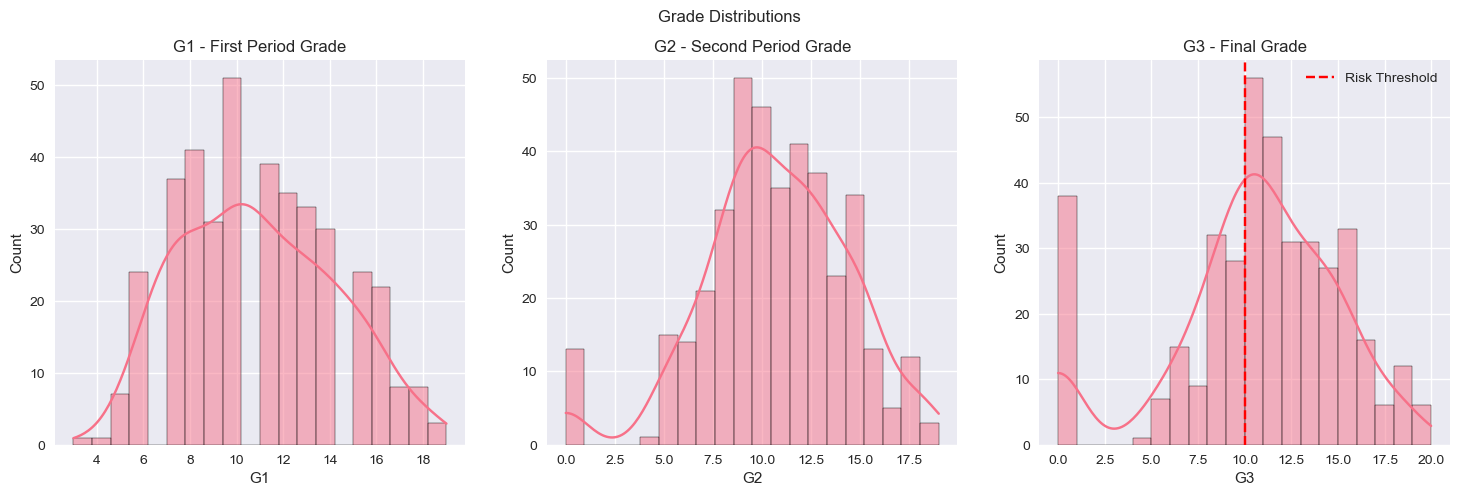

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['G1'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('G1 - First Period Grade')

sns.histplot(df['G2'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('G2 - Second Period Grade')

sns.histplot(df['G3'], bins=20, kde=True, ax=axes[2])
axes[2].set_title('G3 - Final Grade')
axes[2].axvline(10, color='red', linestyle='--', label='Risk Threshold')
axes[2].legend()

plt.suptitle('Grade Distributions')
plt.show()

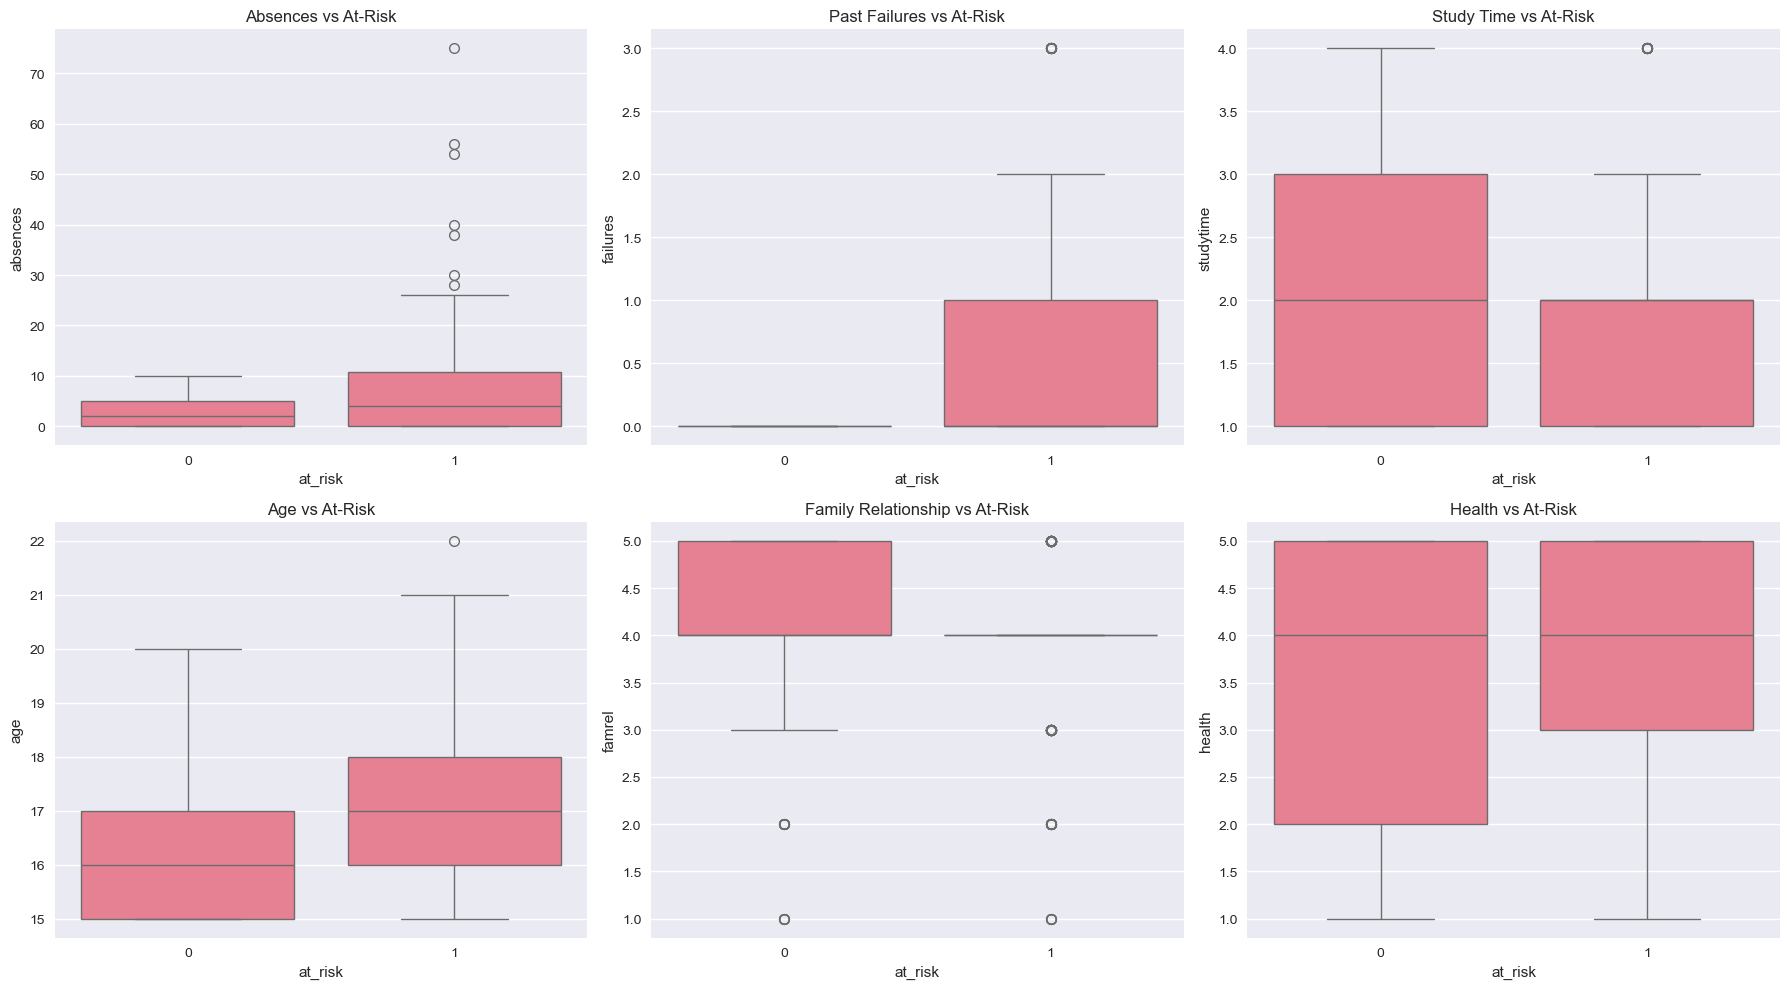

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Absences
sns.boxplot(x='at_risk', y='absences', data=df, ax=axes[0,0])
axes[0,0].set_title('Absences vs At-Risk')

# Failures
sns.boxplot(x='at_risk', y='failures', data=df, ax=axes[0,1])
axes[0,1].set_title('Past Failures vs At-Risk')

# Study Time
sns.boxplot(x='at_risk', y='studytime', data=df, ax=axes[0,2])
axes[0,2].set_title('Study Time vs At-Risk')

# Age
sns.boxplot(x='at_risk', y='age', data=df, ax=axes[1,0])
axes[1,0].set_title('Age vs At-Risk')

# Family Relationship
sns.boxplot(x='at_risk', y='famrel', data=df, ax=axes[1,1])
axes[1,1].set_title('Family Relationship vs At-Risk')

# Health
sns.boxplot(x='at_risk', y='health', data=df, ax=axes[1,2])
axes[1,2].set_title('Health vs At-Risk')

plt.tight_layout()
plt.show()

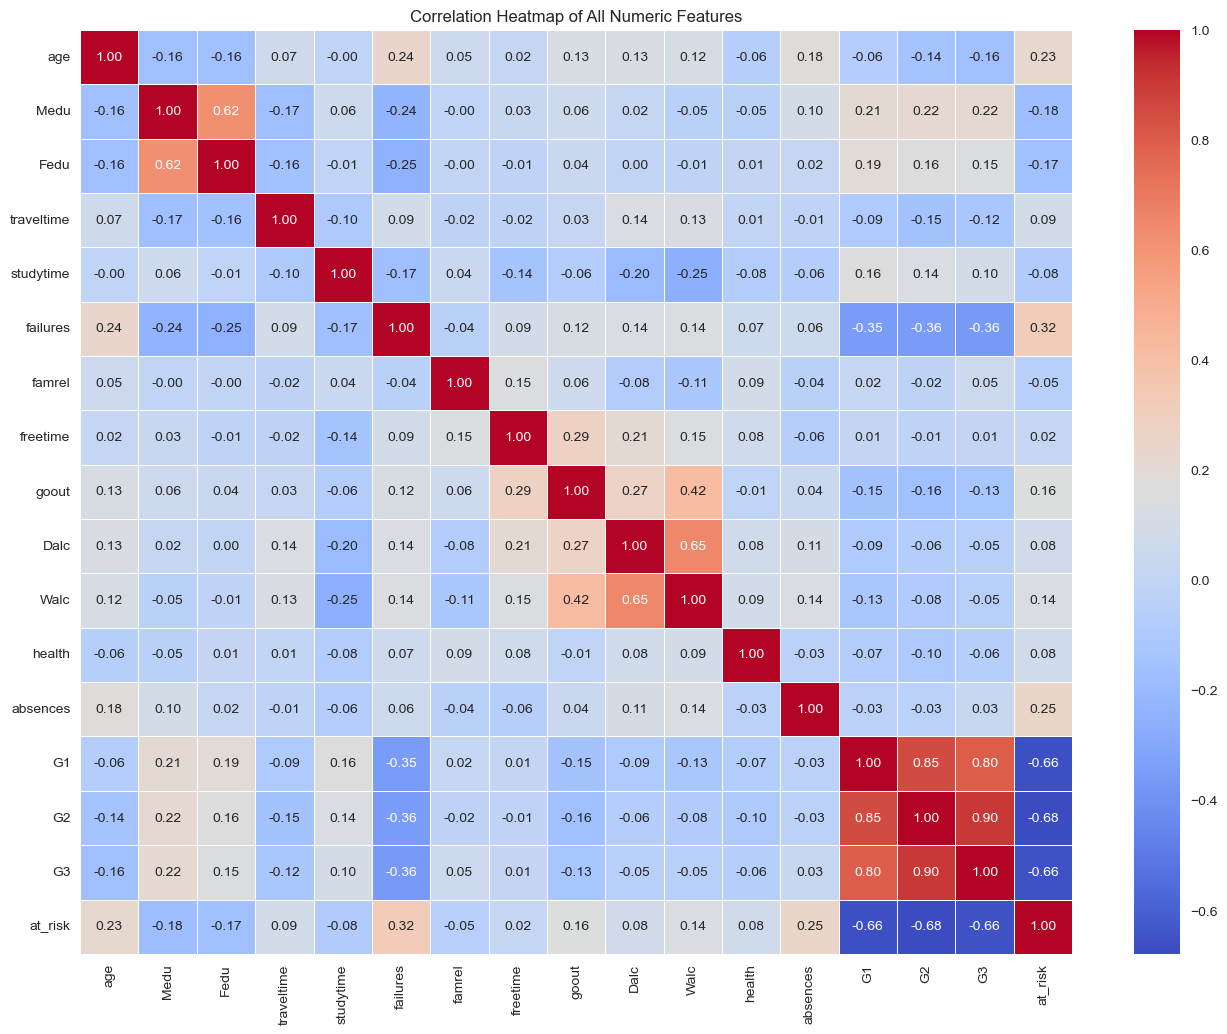

In [15]:
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Numeric Features')
plt.show()

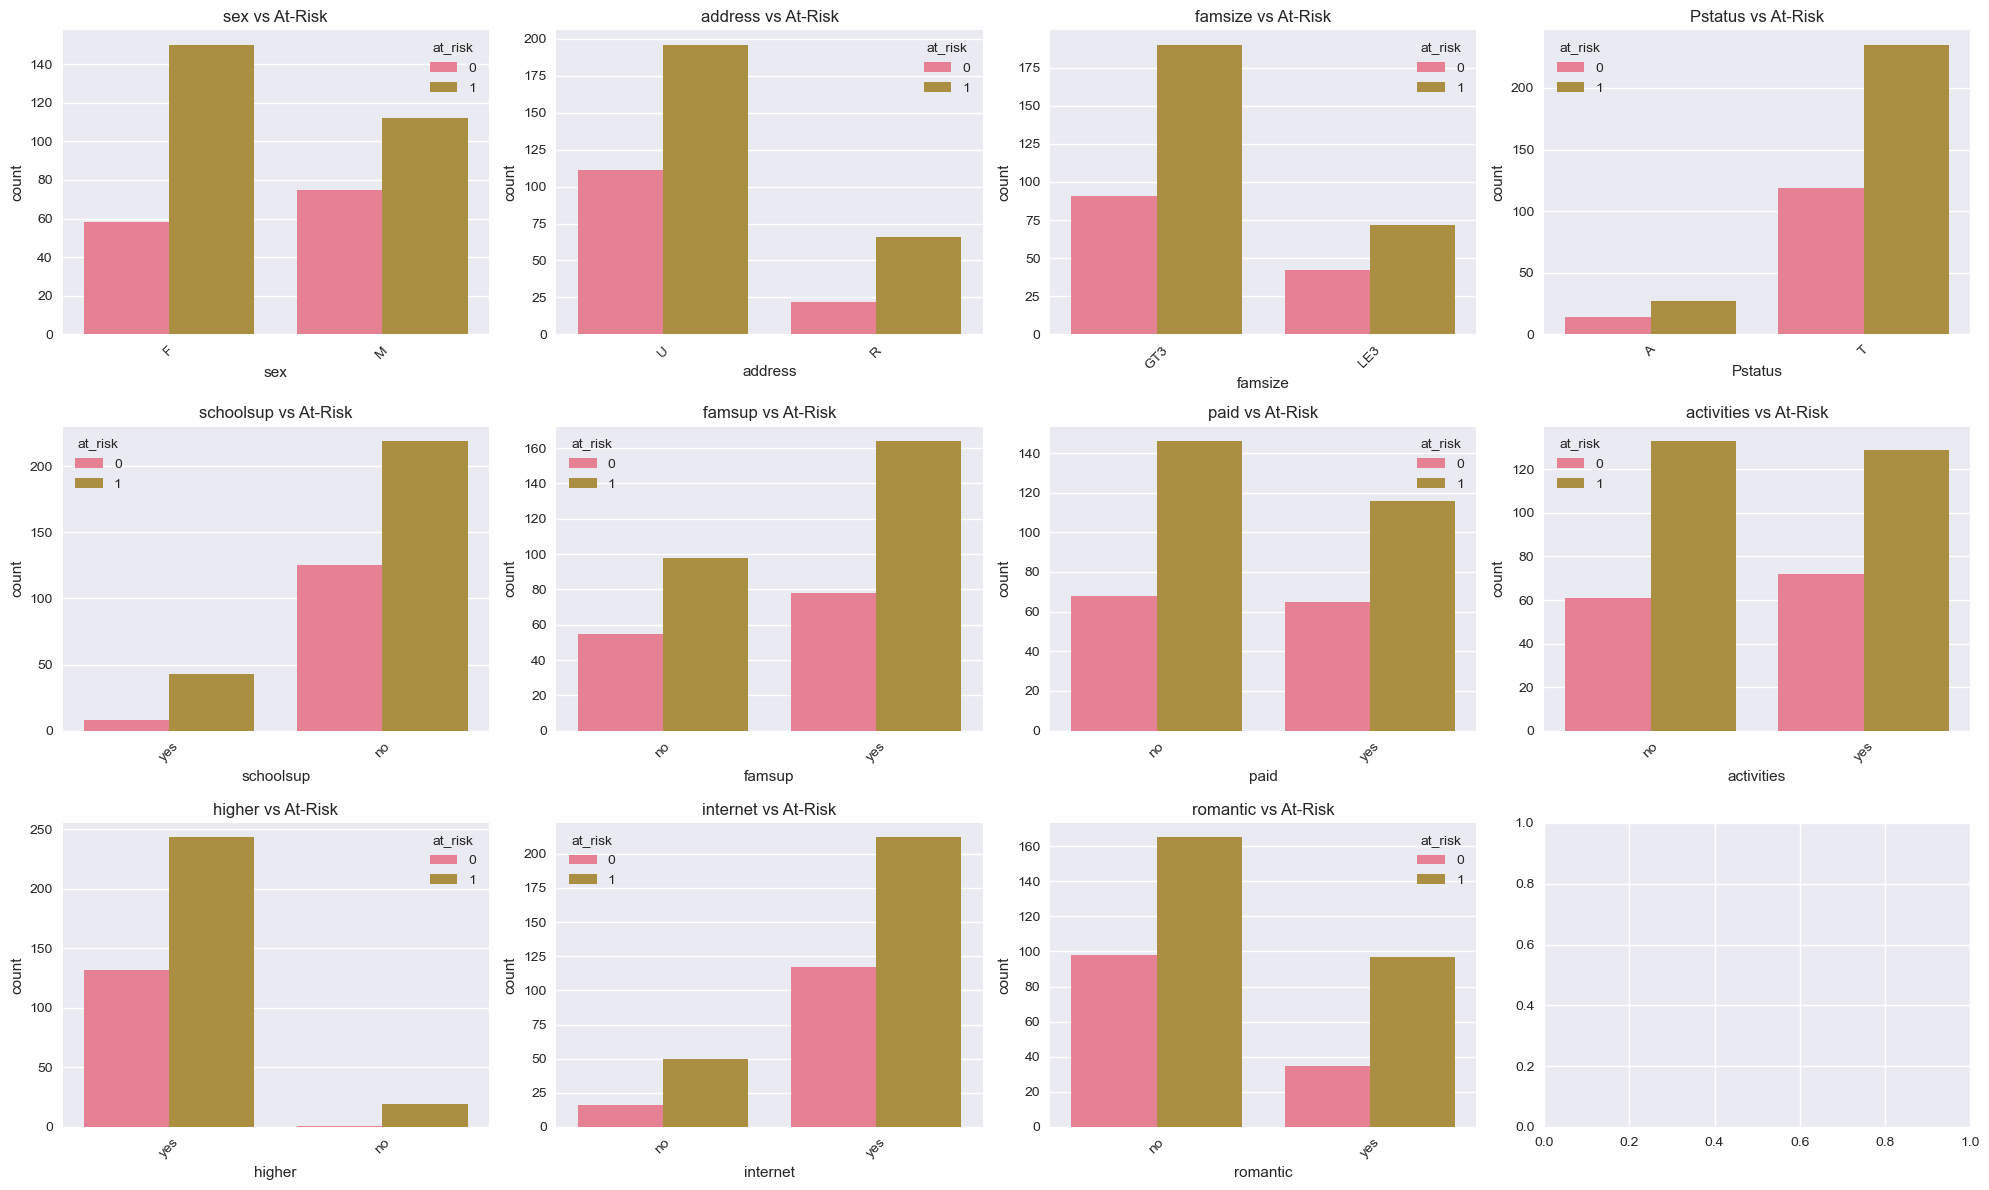

In [16]:
cat_cols = ['sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 
            'paid', 'activities', 'higher', 'internet', 'romantic']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='at_risk', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs At-Risk')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
print("=== KEY INSIGHTS ===")
print(f"1. Total Students: {len(df)}")
print(f"2. At-Risk Students: {df['at_risk'].sum()} ({df['at_risk'].mean()*100:.1f}%)")
print(f"3. Average Final Grade: {df['G3'].mean():.2f}")
print(f"4. Strongest correlations with G3: {df[numeric_df.columns].corr()['G3'].sort_values(ascending=False)[1:6].to_string()}")
print("\nMost important risk factors from plots:")
print("- High absences")
print("- Previous failures")
print("- Low study time")
print("- Urban/Rural address difference")

=== KEY INSIGHTS ===
1. Total Students: 395
2. At-Risk Students: 262 (66.3%)
3. Average Final Grade: 10.42
4. Strongest correlations with G3: G2           0.904868
G1           0.801468
Medu         0.217147
Fedu         0.152457
studytime    0.097820

Most important risk factors from plots:
- High absences
- Previous failures
- Low study time
- Urban/Rural address difference
